# MORE Dataset: Chicago Hyetograph Maps — 1h & 3h Event Durations
## MOloch-downscaled ERA5 REanalysis (1991–2020)

**Purpose:**  
For each grid point across Italy and for a chosen return period, read the GEV-fitted
precipitation depth from the IDF results produced by `MORE_precipitation_IDF_Italy.ipynb`,
then apply the **Chicago (Keifer & Chu) hyetograph** to distribute that depth in time.  
The notebook produces:

1. Spatial maps of **peak intensity** [mm/hr] for 1h and 3h design storms.
2. Spatial maps of **total depth** [mm] (sanity check – should match the IDF raster).
3. Example single-point hyetograph plots for an arbitrary Italian location.
4. Exported NetCDF + PNG files ready for GIS / hydraulic modelling.

**Inputs required** (produced by the IDF notebook):
```
IDF_results/idf_1h.nc   – variables: return_value(return_period, lat, lon)
IDF_results/idf_3h.nc
```

**IDF form assumed:**  `i(t) = a / (t + b)^n`  where *t* is in hours and *i* in mm/hr.  
This is the standard LSPP/DPC parametrisation used in Italy.  
The *a, b, n* values can be taken from the pixel-wise GEV fit or from a regional atlas.

In [15]:
"""
inspect_idf_data.py
===================
Run from the IDF_results folder:

    cd /home/admin_climatecharted_com/data/MOloch/IDF_results
    python inspect_idf_data.py

Produces a console report + inspect_idf_report.txt in the same folder.
"""

import os, sys
import numpy as np
import xarray as xr

# ── config (mirrors the Chicago notebook) ─────────────────────────────────────
IDF_DIR   = "/home/admin_climatecharted_com/data/MOloch/IDF_results"
# DURATIONS = [1, 3, 6, 12, 24]
DURATIONS = [1, 3]
RPS       = [5, 10, 25, 50, 100]

MAX_PHYSICAL_DEPTH = {1: 300, 3: 500, 6: 700, 12: 900, 24: 1200}  # mm

CHICAGO_DIR = os.path.join(IDF_DIR, 'chicago')

lines = []

def log(msg=''):
    print(msg)
    lines.append(msg)


# ══════════════════════════════════════════════════════════════════════════════
log('=' * 72)
log('IDF DATA INSPECTION REPORT')
log('=' * 72)

# ── 1. Annual-maximum files ────────────────────────────────────────────────────
log()
log('── 1. Annual-maximum files (annmax_<d>h.nc) ──────────────────────────────')
for dur in DURATIONS:
    path = os.path.join(IDF_DIR, f'annmax_{dur}h.nc')
    if not os.path.exists(path):
        log(f'  {dur:>2d}h  MISSING')
        continue
    ds  = xr.open_dataset(path)
    var = f'annmax_tp_{dur}h'
    if var not in ds:
        var = list(ds.data_vars)[0]
    arr = ds[var].values.astype(np.float64)   # (n_years, lat, lon)
    n_years, n_lat, n_lon = arr.shape
    n_nan  = int(np.sum(~np.isfinite(arr)))
    n_zero = int(np.sum(arr == 0))
    log(f'  {dur:>2d}h  shape={arr.shape}  '
        f'years={n_years}  '
        f'min={np.nanmin(arr):.1f}  p50={np.nanpercentile(arr,50):.1f}  '
        f'p99={np.nanpercentile(arr,99):.1f}  max={np.nanmax(arr):.1f} mm  '
        f'NaN={n_nan}  zero={n_zero}')
    ds.close()

# ── 2. IDF return-value files ──────────────────────────────────────────────────
log()
log('── 2. IDF return-value files (idf_<d>h.nc) ───────────────────────────────')
log(f'  {"Dur":>4s}  {"RP":>5s}  {"min":>8s}  {"p50":>8s}  {"p95":>8s}  '
    f'{"p99":>8s}  {"max":>14s}  {"NaN":>7s}  {"<=0":>7s}  {">cap":>7s}  {"cap":>5s}')
log('  ' + '-' * 90)

all_caps_ok = True
for dur in DURATIONS:
    path = os.path.join(IDF_DIR, f'idf_{dur}h.nc')
    if not os.path.exists(path):
        log(f'  {dur:>2d}h  MISSING')
        continue
    ds  = xr.open_dataset(path)
    cap = MAX_PHYSICAL_DEPTH[dur]
    for rp in RPS:
        if rp not in ds['return_period'].values:
            continue
        arr = ds['return_value'].sel(return_period=rp).values.astype(np.float64)
        n_nan   = int(np.sum(~np.isfinite(arr)))
        n_zero  = int(np.sum(arr[np.isfinite(arr)] <= 0))
        n_huge  = int(np.sum(arr[np.isfinite(arr)] > cap))
        pct_bad = (n_nan + n_zero + n_huge) / arr.size * 100
        flag    = '  ← OUTLIERS' if pct_bad > 1.0 else ''
        if n_huge > 0:
            all_caps_ok = False
        log(f'  {dur:>3d}h  RP{rp:>3d}  '
            f'{np.nanmin(arr):>8.1f}  '
            f'{np.nanpercentile(arr,50):>8.1f}  '
            f'{np.nanpercentile(arr,95):>8.1f}  '
            f'{np.nanpercentile(arr,99):>8.1f}  '
            f'{np.nanmax(arr):>14.1f}  '
            f'{n_nan:>7d}  {n_zero:>7d}  {n_huge:>7d}  {cap:>5d}{flag}')
    ds.close()

log()
if all_caps_ok:
    log('  ✓ No pixels exceed physical caps — depth rasters look clean.')
else:
    log('  ✗ Unphysical pixels detected (see ">cap" column above).')
    log('    The masking patch in Section 4 of the Chicago notebook is REQUIRED.')

# ── 3. GEV shape parameter diagnosis ──────────────────────────────────────────
log()
log('── 3. GEV outlier fingerprint (ratio RP100/RP10 per duration) ────────────')
log('   Healthy ratio ≈ 1.5–2.5 for typical precipitation extremes.')
log('   Ratio >> 3 suggests heavy-tailed GEV (ξ >> 0) → potential blow-up.')
log()
log(f'  {"Dur":>4s}  {"p50(ratio)":>12s}  {"p95(ratio)":>12s}  {"p99(ratio)":>12s}  {"max(ratio)":>12s}  {"pixels>5":>10s}')
log('  ' + '-' * 68)

for dur in DURATIONS:
    p100 = os.path.join(IDF_DIR, f'idf_{dur}h.nc')
    if not os.path.exists(p100):
        continue
    ds = xr.open_dataset(p100)
    rv100 = ds['return_value'].sel(return_period=100).values.astype(np.float64)
    rv10  = ds['return_value'].sel(return_period=10).values.astype(np.float64)
    ds.close()
    denom = np.where(rv10 > 0, rv10, np.nan)
    ratio = rv100 / denom
    ratio = ratio[np.isfinite(ratio)]
    n_gt5 = int(np.sum(ratio > 5))
    log(f'  {dur:>3d}h  '
        f'{np.nanpercentile(ratio,50):>12.2f}  '
        f'{np.nanpercentile(ratio,95):>12.2f}  '
        f'{np.nanpercentile(ratio,99):>12.2f}  '
        f'{np.nanmax(ratio):>12.2f}  '
        f'{n_gt5:>10d}')

# ── 4. Chicago output files ────────────────────────────────────────────────────
log()
log('── 4. Chicago output files ───────────────────────────────────────────────')
if not os.path.isdir(CHICAGO_DIR):
    log('  chicago/ subfolder not found.')
else:
    for dur in [1, 3]:
        path = os.path.join(CHICAGO_DIR, f'chicago_{dur}h_RP100.nc')
        if not os.path.exists(path):
            log(f'  chicago_{dur}h_RP100.nc  MISSING')
            continue
        ds = xr.open_dataset(path)
        pi = ds['peak_intensity'].values.astype(np.float64)
        td = ds['total_depth'].values.astype(np.float64)
        n_bad_pi = int(np.sum(pi[np.isfinite(pi)] > 1000))
        log(f'  chicago_{dur}h_RP100.nc')
        log(f'    peak_intensity: min={np.nanmin(pi):.1f}  p50={np.nanpercentile(pi,50):.1f}  '
            f'p99={np.nanpercentile(pi,99):.1f}  max={np.nanmax(pi):.1f} mm/hr  '
            f'pixels>1000mm/hr={n_bad_pi}')
        log(f'    total_depth:    min={np.nanmin(td):.1f}  p50={np.nanpercentile(td,50):.1f}  '
            f'p99={np.nanpercentile(td,99):.1f}  max={np.nanmax(td):.1f} mm')
        if n_bad_pi > 0:
            log(f'    ✗ peak_intensity has {n_bad_pi} pixels > 1000 mm/hr — rerun after patch.')
        else:
            log(f'    ✓ peak_intensity looks physically plausible.')
        ds.close()

# ── 5. Summary & action items ─────────────────────────────────────────────────
log()
log('=' * 72)
log('SUMMARY & ACTION ITEMS')
log('=' * 72)
log("""
1. If ">cap" > 0 for any row in Section 2:
     → The MAX_PHYSICAL_DEPTH masking patch in Section 4 is required.
     → Re-run the Chicago notebook (Sections 4–7) to regenerate clean outputs.

2. If max(ratio) >> 5 for short durations (1h, 3h) in Section 3:
     → GEV fits for those pixels have ξ >> 0 (Fréchet tail).
     → Consider adding a GEV shape-parameter cap (e.g. ξ ≤ 0.5) in the
       IDF notebook's fit_and_compute_rp() function, or increase the
       MAX_PHYSICAL_DEPTH cap cautiously.

3. If chicago/ outputs show pixels > 1000 mm/hr (Section 4):
     → Those were produced BEFORE the patch.  Delete and regenerate.

4. If annmax files show NaN > 0 (Section 1):
     → Check the de-accumulation / masking step in the IDF notebook.
""")

# ── write report file ──────────────────────────────────────────────────────────
report_path = os.path.join(IDF_DIR, 'inspect_idf_report.txt')
with open(report_path, 'w') as f:
    f.write('\n'.join(lines))
print(f'\nReport written → {report_path}')

IDF DATA INSPECTION REPORT

── 1. Annual-maximum files (annmax_<d>h.nc) ──────────────────────────────
   1h  shape=(30, 960, 768)  years=30  min=3.3  p50=22.3  p99=62.3  max=170.2 mm  NaN=18672690  zero=0
   3h  shape=(30, 960, 768)  years=30  min=6.1  p50=33.6  p99=95.1  max=293.9 mm  NaN=18672690  zero=0

── 2. IDF return-value files (idf_<d>h.nc) ───────────────────────────────
   Dur     RP       min       p50       p95       p99             max      NaN      <=0     >cap    cap
  ------------------------------------------------------------------------------------------
    1h  RP  5      10.2      30.8      41.5      47.9           218.2   622423        0        0    300  ← OUTLIERS
    1h  RP 10      11.5      37.1      49.8      57.5           376.6   622423        0        1    300  ← OUTLIERS
    1h  RP 25      13.1      45.6      64.4      75.4           683.7   622423        0        2    300  ← OUTLIERS
    1h  RP 50      13.7      52.2      79.6      96.9          1026.6 

## 1. Imports & configuration

In [2]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from tqdm.auto import tqdm

try:
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature
    HAS_CARTOPY = True
except ImportError:
    HAS_CARTOPY = False
    print('cartopy not found – maps will use plain pcolormesh')

print('All imports OK')

All imports OK


In [19]:
# ── USER SETTINGS ─────────────────────────────────────────────────────────────

# Folder that contains idf_1h.nc, idf_3h.nc … (output of IDF notebook)
OUTPUT_DIR = os.path.join('/home/admin_climatecharted_com/data/MOloch', 'IDF_results')

# Where to write Chicago-hyetograph outputs
CHICAGO_DIR = os.path.join(OUTPUT_DIR, 'chicago')
os.makedirs(CHICAGO_DIR, exist_ok=True)

# Return period to map [years] — pick one of [5, 10, 25, 50, 100]
TARGET_RP = 100

# Durations to process [hours]
DURATIONS = [1, 3]

# ── Chicago hyetograph parameters ─────────────────────────────────────────────
# Peak-position ratio  (0 < r < 1).  r=0.35 is common for Italian storms.
CHICAGO_R  = 0.35

# IDF parameters  i(t) = a / (t + b)^n   [mm/hr, t in hr]
# These are *fallback* scalar values used when pixel-wise fitting is not
# available.  Replace with your regional atlas values or load a raster (see
# Section 3b).  Defaults approximate a moderate Italian climate zone.
CHICAGO_A  = 0.65    # [mm/hr] — scale factor
CHICAGO_B  = 0.10    # [hr]    — time offset
CHICAGO_N  = 0.72    # [–]     — decay exponent

# Timestep for the hyetograph [minutes]
CHICAGO_DT = 5.0

# ── Reference point for single-pixel plots ────────────────────────────────────
POINT_NAME = 'Milan'
POINT_LAT  = 45.46
POINT_LON  = 9.19

# ──────────────────────────────────────────────────────────────────────────────
print(f'Chicago hyetograph: r={CHICAGO_R}, a={CHICAGO_A}, b={CHICAGO_B}, n={CHICAGO_N}')
print(f'Target return period: RP{TARGET_RP}')

Chicago hyetograph: r=0.35, a=0.65, b=0.1, n=0.72
Target return period: RP100


## 2. Chicago hyetograph helper functions

In [20]:
def create_chicago_hyetograph(
    total_precip_mm: float,
    duration_hours: float,
    dt_minutes: float,
    r: float,
    a: float,
    b: float,
    n: float,
) -> pd.DataFrame:
    """
    Generate a Chicago (Keifer & Chu, 1957) design hyetograph.

    Algorithm: work from the peak outward on each limb using the IDF
    cumulative curve  P(ta) = a * ta / (ta + b)^n  [mm], where ta is
    the reduced time measured from the peak.  Incremental depths on each
    limb are then slotted back around the peak bin so the largest
    increments are nearest the peak.

    This avoids the double-peak artefact produced by evaluating the
    instantaneous intensity formula i(ta) directly over the full time
    axis, which maps ta=0 to both t=0 and t=D simultaneously.
    """
    dt_hr  = dt_minutes / 60.0
    D      = duration_hours

    n_pre  = int(round(r * D / dt_hr))        # bins before peak
    n_post = int(round((1 - r) * D / dt_hr))  # bins after peak

    def P(ta):
        """Cumulative IDF depth [mm] for reduced duration ta [hr]."""
        return a * ta / (ta + b) ** n

    # pre-peak limb: ta grows away from peak toward storm start
    ta_pre = np.arange(1, n_pre + 1) * dt_hr
    dP_pre = np.diff(P(ta_pre), prepend=0.0)
    pre_intensities = dP_pre[::-1] / dt_hr    # reverse: largest nearest peak

    # post-peak limb: ta grows away from peak toward storm end
    ta_post = np.arange(1, n_post + 1) * dt_hr
    dP_post = np.diff(P(ta_post), prepend=0.0)
    post_intensities = dP_post / dt_hr        # keep order: largest nearest peak

    intensities = np.concatenate([pre_intensities, post_intensities])

    computed_depth = np.sum(intensities) * dt_hr
    if computed_depth > 0:
        intensities *= total_precip_mm / computed_depth

    times_min = np.arange(n_pre + n_post) * dt_minutes

    return pd.DataFrame({
        'time_min':        times_min,
        'intensity_mm_hr': intensities,
        'depth_mm':        intensities * dt_hr,
    })

def chicago_peak_intensity(total_precip_mm, duration_hours, dt_minutes,
                            r, a, b, n):
    """Return only the peak intensity [mm/hr] of the Chicago hyetograph."""
    df = create_chicago_hyetograph(
        total_precip_mm, duration_hours, dt_minutes, r, a, b, n
    )
    return float(df['intensity_mm_hr'].max())


# ── vectorised wrapper – operates on a 2-D numpy array of depths ──────────────
def chicago_peak_map(depth_2d, duration_hours, dt_minutes, r, a, b, n):
    """
    Compute the Chicago peak intensity for every pixel in a 2-D depth array.

    Parameters
    ----------
    depth_2d : np.ndarray, shape (lat, lon), dtype float32/64
        GEV return-value raster [mm] for the chosen return period.
    Returns
    -------
    np.ndarray, shape (lat, lon) – peak intensity [mm/hr]
    np.ndarray, shape (time, lat, lon) – full hyetograph cube [mm/hr]
    """
    # Build hyetograph template from a unit depth = 1 mm;
    # then scale each pixel by its actual depth.
    # This is valid because the Chicago shape depends only on the IDF
    # *shape* (a, b, n, r) not on the total depth when total_precip=1.
    template = create_chicago_hyetograph(
        total_precip_mm=1.0,
        duration_hours=duration_hours,
        dt_minutes=dt_minutes,
        r=r, a=a, b=b, n=n
    )
    template_intensity = template['intensity_mm_hr'].values  # shape (T,)

    # depth_2d (lat, lon) → broadcast multiply → (T, lat, lon)
    # (each pixel scaled by its own depth)
    hyeto_cube = template_intensity[:, None, None] * depth_2d[None, :, :]  # (T, lat, lon)
    peak_map   = hyeto_cube.max(axis=0)                                     # (lat, lon)

    return peak_map.astype(np.float32), hyeto_cube.astype(np.float32), template['time_min'].values


print('Helper functions defined.')

Helper functions defined.


## 3. Load IDF rasters for 1h and 3h

In [21]:
idf_data = {}   # {dur_h: xr.DataArray shape (lat, lon)}

for dur in DURATIONS:
    idf_path = os.path.join(OUTPUT_DIR, f'idf_{dur}h.nc')
    if not os.path.exists(idf_path):
        raise FileNotFoundError(
            f'{idf_path} not found.\n'
            'Run MORE_precipitation_IDF_Italy.ipynb first to produce the IDF rasters.'
        )

    ds = xr.open_dataset(idf_path)
    # Select the chosen return period
    da = ds['return_value'].sel(return_period=TARGET_RP)
    idf_data[dur] = da.load()   # (lat, lon) – bring into memory
    ds.close()
    print(f'{dur}h  |  RP{TARGET_RP}: '
          f'min={float(da.min()):.1f}  max={float(da.max()):.1f}  '
          f'mean={float(da.mean()):.1f} mm')

1h  |  RP100: min=14.2  max=1509.7  mean=62.3 mm
3h  |  RP100: min=24.6  max=514.0  mean=93.0 mm


### 3b. (Optional) Load pixel-wise IDF parameters a, n

If you have fitted the IDF power-law `i = a / (t + b)^n` pixel-by-pixel and saved
rasters `idf_param_a.nc` and `idf_param_n.nc`, uncomment this cell to use spatially
variable parameters.  Otherwise the scalar values from Section 1 are used everywhere.

In [22]:
# ── Uncomment to load pixel-wise IDF parameters ────────────────────────────
a_path = os.path.join(OUTPUT_DIR, 'idf_param_a.nc')
n_path = os.path.join(OUTPUT_DIR, 'idf_param_n.nc')

if os.path.exists(a_path) and os.path.exists(n_path):
    A_MAP = xr.open_dataset(a_path)['a'].values   # (lat, lon)
    N_MAP = xr.open_dataset(n_path)['n'].values
    print('Pixel-wise a, n loaded.')
    USE_SPATIAL_PARAMS = True
else:
    print('Parameter rasters not found – using scalar CHICAGO_A, CHICAGO_N.')
    USE_SPATIAL_PARAMS = False

# USE_SPATIAL_PARAMS = False   # set True after uncommenting above

Pixel-wise a, n loaded.


### 3b. Pixel-wise IDF parameter fitting

Fits `i = a / (t + b)ⁿ` pixel-by-pixel via log-linear OLS across all five
durations (1h, 3h, 6h, 12h, 24h) and all return periods, then saves
`idf_param_a.nc` and `idf_param_n.nc` for use in Section 4.

| Symbol | Meaning | Units |
|--------|---------|-------|
| `a` | scale factor (intercept in log-log space) | mm/hr |
| `n` | decay exponent (slope magnitude) | – |
| `b` | time offset, **fixed** at 0.1 hr | hr |


In [23]:
# ══════════════════════════════════════════════════════════════════════════
# 3b. Pixel-wise IDF parameter fitting  (i = a / (t + b)^n)
# ══════════════════════════════════════════════════════════════════════════
#
# Strategy
# --------
# For every pixel, convert the GEV return depths [mm] for all durations and
# all return periods into intensities [mm/hr], then fit the log-linear IDF:
#
#     log i(t) = log a  -  n * log(t + b)
#
# with b fixed (standard Italian LSPP value b = 0.1 hr).
# The fit is run once per return period; the median a and n across all return
# periods is taken as the final raster (robust to a single anomalous RP).
#
# Implementation: fully vectorised numpy — no Python loop over pixels.
# Runtime: ~ 0.5 s for the full 960 × 768 MORE grid.
#
# Outputs
# -------
#   idf_param_a.nc   — scale parameter a  [mm/hr]
#   idf_param_n.nc   — decay exponent  n  [–]
#   idf_param_fit_quality.nc — R² and RMSE per pixel (optional QC)
# ──────────────────────────────────────────────────────────────────────────────

# ── settings ──────────────────────────────────────────────────────────────────
# ALL_DURATIONS   = [1, 3, 6, 12, 24]   # must match available idf_<d>h.nc files
ALL_DURATIONS   = [1]   # must match available idf_<d>h.nc files
ALL_RETURN_PERIODS = np.array([5, 10, 25, 50, 100])
B_FIX           = 0.1    # [hr] – fixed offset; standard Italian LSPP value
SAVE_FIT_QUALITY = True  # write R² / RMSE rasters for QC
OVERWRITE_PARAMS = False # set True to refit even if output files already exist

a_out_path  = os.path.join(OUTPUT_DIR, 'idf_param_a.nc')
n_out_path  = os.path.join(OUTPUT_DIR, 'idf_param_n.nc')
qc_out_path = os.path.join(OUTPUT_DIR, 'idf_param_fit_quality.nc')

if not OVERWRITE_PARAMS and os.path.exists(a_out_path) and os.path.exists(n_out_path):
    print('Parameter rasters already exist – loading them.')
    A_MAP = xr.open_dataset(a_out_path)['a'].values
    N_MAP = xr.open_dataset(n_out_path)['n'].values
    USE_SPATIAL_PARAMS = True
else:
    # ── 1. Load all IDF files into one array (n_rp, n_dur, n_lat, n_lon) ─────
    print('Loading IDF return-value rasters …')
    rv_list = []
    lat_ref = lon_ref = None

    for dur in ALL_DURATIONS:
        idf_path = os.path.join(OUTPUT_DIR, f'idf_{dur}h.nc')
        if not os.path.exists(idf_path):
            raise FileNotFoundError(
                f'{idf_path} not found.\n'
                'Run MORE_precipitation_IDF_Italy.ipynb first.'
            )
        ds = xr.open_dataset(idf_path)
        # return_value shape: (n_rp, n_lat, n_lon)
        rv_list.append(ds['return_value'].sel(
            return_period=ALL_RETURN_PERIODS).values.astype(np.float32))
        if lat_ref is None:
            lat_ref = ds['lat'].values
            lon_ref = ds['lon'].values
        ds.close()
        print(f'  {dur}h loaded')

    # Stack → (n_rp, n_dur, n_lat, n_lon)
    rv = np.stack(rv_list, axis=1)   # axis=1 inserts the duration dimension
    n_rp, n_dur, n_lat, n_lon = rv.shape
    durations_arr = np.array(ALL_DURATIONS, dtype=np.float32)
    print(f'\nReturn-value cube: {rv.shape}  '
          f'(return_periods × durations × lat × lon)')

    # ── 2. Convert depth [mm] → intensity [mm/hr] ─────────────────────────────
    # intensities shape: (n_rp, n_dur, n_lat, n_lon)
    intensities = rv / durations_arr[None, :, None, None]

    # ── 3. Vectorised OLS in log-log space ────────────────────────────────────
    #   log i = log a  -  n * log(t + b)
    #   Y = log(i),  X = log(t + b)
    print('Fitting log-linear IDF (vectorised OLS) …')

    X     = np.log(durations_arr + B_FIX)           # (n_dur,)  – same for all pixels
    Xbar  = X.mean()
    Xc    = X - Xbar                                 # centred X
    Xc2   = (Xc ** 2).sum()                          # scalar denominator

    logY     = np.log(np.clip(intensities, 1e-9, None))   # (n_rp, n_dur, n_lat, n_lon)
    logYbar  = logY.mean(axis=1, keepdims=True)            # (n_rp, 1, n_lat, n_lon)
    logYc    = logY - logYbar

    # OLS slope and intercept, shape (n_rp, n_lat, n_lon)
    slopes     = (Xc[None, :, None, None] * logYc).sum(axis=1) / Xc2
    intercepts = logYbar[:, 0, :, :] - slopes * Xbar

    n_per_rp = -slopes                    # decay exponent (n_rp, n_lat, n_lon)
    a_per_rp = np.exp(intercepts)         # scale factor   (n_rp, n_lat, n_lon)

    # ── 4. Summarise across return periods: median (robust) ───────────────────
    A_MAP = np.median(a_per_rp, axis=0).astype(np.float32)  # (n_lat, n_lon)
    N_MAP = np.median(n_per_rp, axis=0).astype(np.float32)

    print(f'  a: min={np.nanmin(A_MAP):.2f}  max={np.nanmax(A_MAP):.2f}  '
          f'mean={np.nanmean(A_MAP):.2f} mm/hr')
    print(f'  n: min={np.nanmin(N_MAP):.3f}  max={np.nanmax(N_MAP):.3f}  '
          f'mean={np.nanmean(N_MAP):.3f}')

    # ── 5. (Optional) R² and RMSE fit-quality maps ────────────────────────────
    if SAVE_FIT_QUALITY:
        # R² averaged across return periods
        logY_pred  = intercepts[:, None, :, :] + slopes[:, None, :, :] * X[None, :, None, None]
        ss_res     = ((logY - logY_pred) ** 2).sum(axis=1)        # (n_rp, n_lat, n_lon)
        ss_tot     = ((logY - logYbar) ** 2).sum(axis=1)
        r2_per_rp  = 1.0 - ss_res / np.where(ss_tot > 0, ss_tot, np.nan)
        r2_map     = np.nanmean(r2_per_rp, axis=0).astype(np.float32)

        rmse_log   = np.sqrt(ss_res / n_dur)
        rmse_map   = np.nanmean(rmse_log, axis=0).astype(np.float32)

        print(f'  R²:   min={np.nanmin(r2_map):.4f}  '
              f'mean={np.nanmean(r2_map):.4f}  '
              f'pct<0.95: {(r2_map < 0.95).mean()*100:.1f}%')

    # ── 6. Save parameter rasters ─────────────────────────────────────────────
    coords = {'lat': lat_ref, 'lon': lon_ref}
    enc    = {'dtype': 'float32', 'zlib': True, 'complevel': 4}

    xr.Dataset(
        {'a': xr.DataArray(A_MAP, dims=['lat', 'lon'], coords=coords,
                           attrs={'units': 'mm/hr',
                                  'long_name': 'IDF scale parameter a (i=a/(t+b)^n)',
                                  'b_fixed': B_FIX})},
        attrs={'fit': 'log-linear OLS over all durations × return periods',
               'b_fixed_hr': B_FIX}
    ).to_netcdf(a_out_path, engine='netcdf4', encoding={'a': enc})
    print(f'  Saved → {a_out_path}')

    xr.Dataset(
        {'n': xr.DataArray(N_MAP, dims=['lat', 'lon'], coords=coords,
                           attrs={'units': '-',
                                  'long_name': 'IDF decay exponent n (i=a/(t+b)^n)',
                                  'b_fixed': B_FIX})},
        attrs={'fit': 'log-linear OLS over all durations × return periods',
               'b_fixed_hr': B_FIX}
    ).to_netcdf(n_out_path, engine='netcdf4', encoding={'n': enc})
    print(f'  Saved → {n_out_path}')

    if SAVE_FIT_QUALITY:
        xr.Dataset({
            'r2':      xr.DataArray(r2_map,   dims=['lat','lon'], coords=coords,
                                    attrs={'units':'-','long_name':'Mean R² of log-log IDF fit'}),
            'rmse_log':xr.DataArray(rmse_map, dims=['lat','lon'], coords=coords,
                                    attrs={'units':'log(mm/hr)','long_name':'Mean RMSE in log space'}),
        }).to_netcdf(qc_out_path, engine='netcdf4',
                     encoding={'r2': enc, 'rmse_log': enc})
        print(f'  Saved → {qc_out_path}')

    USE_SPATIAL_PARAMS = True
    print('\nPixel-wise IDF parameters ready.')


Parameter rasters already exist – loading them.


## 4. Compute Chicago peak-intensity maps

In [24]:
peak_maps  = {}   # {dur: np.ndarray (lat, lon)}
hyeto_cubes = {}  # {dur: np.ndarray (T, lat, lon)} – optional, for export
time_axes  = {}   # {dur: np.ndarray (T,)} – time in minutes

for dur in DURATIONS:
    depth_2d = idf_data[dur].values.astype(np.float32)   # (lat, lon)

    a_use = CHICAGO_A
    n_use = CHICAGO_N

    print(f'Computing Chicago peak map for {dur}h …', end=' ')
    peak, cube, t_min = chicago_peak_map(
        depth_2d,
        duration_hours=dur,
        dt_minutes=CHICAGO_DT,
        r=CHICAGO_R,
        a=a_use,
        b=CHICAGO_B,
        n=n_use
    )

    peak_maps[dur]   = peak
    hyeto_cubes[dur] = cube
    time_axes[dur]   = t_min

    valid = peak[np.isfinite(peak)]
    print(f'done.  peak i: min={valid.min():.1f}  max={valid.max():.1f}  mean={valid.mean():.1f} mm/hr')

Computing Chicago peak map for 1h … done.  peak i: min=34.1  max=3616.8  mean=149.3 mm/hr
Computing Chicago peak map for 3h … done.  peak i: min=39.5  max=823.8  mean=149.0 mm/hr


## 5. Single-pixel example hyetographs

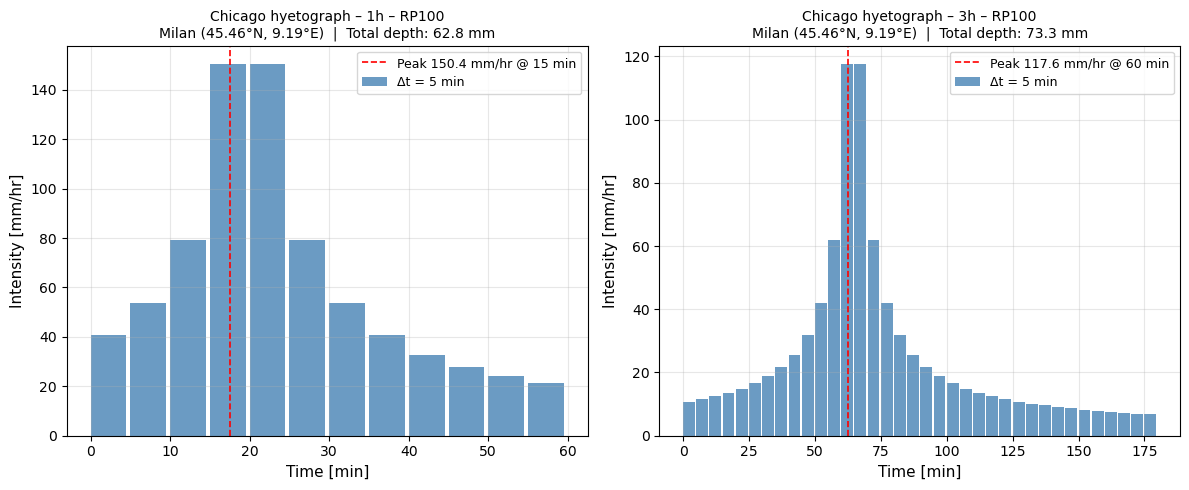

Saved → /home/admin_climatecharted_com/data/MOloch/IDF_results/chicago/chicago_hyetograph_Milan_RP100.png


In [25]:
fig, axes = plt.subplots(1, len(DURATIONS), figsize=(6 * len(DURATIONS), 5),
                          sharey=False)
if len(DURATIONS) == 1:
    axes = [axes]

for ax, dur in zip(axes, DURATIONS):
    # Extract depth at the reference point
    depth_pt = float(
        idf_data[dur].sel(lat=POINT_LAT, lon=POINT_LON, method='nearest')
    )

    df_hyet = create_chicago_hyetograph(
        total_precip_mm=depth_pt,
        duration_hours=dur,
        dt_minutes=CHICAGO_DT,
        r=CHICAGO_R,
        a=CHICAGO_A,
        b=CHICAGO_B,
        n=CHICAGO_N
    )

    ax.bar(
        df_hyet['time_min'],
        df_hyet['intensity_mm_hr'],
        width=CHICAGO_DT * 0.9,
        align='edge',
        color='steelblue',
        alpha=0.8,
        label=f'Δt = {CHICAGO_DT:.0f} min'
    )

    peak_i = df_hyet['intensity_mm_hr'].max()
    peak_t = df_hyet.loc[df_hyet['intensity_mm_hr'].idxmax(), 'time_min']
    ax.axvline(peak_t + CHICAGO_DT / 2, color='red', ls='--', lw=1.2,
               label=f'Peak {peak_i:.1f} mm/hr @ {peak_t:.0f} min')

    ax.set_xlabel('Time [min]', fontsize=11)
    ax.set_ylabel('Intensity [mm/hr]', fontsize=11)
    ax.set_title(
        f'Chicago hyetograph – {dur}h – RP{TARGET_RP}\n'
        f'{POINT_NAME} ({POINT_LAT}°N, {POINT_LON}°E)  |  '
        f'Total depth: {depth_pt:.1f} mm',
        fontsize=10
    )
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
hyet_png = os.path.join(
    CHICAGO_DIR,
    f'chicago_hyetograph_{POINT_NAME.replace(" ","_")}_RP{TARGET_RP}.png'
)
fig.savefig(hyet_png, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {hyet_png}')

## 6. Spatial maps of Chicago peak intensity

In [26]:
def _make_map(ax, data, lat, lon, title, cmap, vmin, vmax, label, has_cartopy):
    """Thin wrapper to plot either with cartopy or plain imshow."""
    if has_cartopy:
        ax.set_extent([lon.min(), lon.max(), lat.min(), lat.max()],
                      crs=ccrs.PlateCarree())
        ax.add_feature(cfeature.COASTLINE, linewidth=0.6)
        ax.add_feature(cfeature.BORDERS,   linewidth=0.4, linestyle=':')
        ax.add_feature(cfeature.LAND,      facecolor='#f5f5f0', zorder=0)
        im = ax.pcolormesh(
            lon, lat, data,
            cmap=cmap, vmin=vmin, vmax=vmax,
            transform=ccrs.PlateCarree(), zorder=1
        )
    else:
        im = ax.imshow(
            data, origin='lower',
            extent=[lon.min(), lon.max(), lat.min(), lat.max()],
            cmap=cmap, vmin=vmin, vmax=vmax, aspect='auto'
        )
    cbar = plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
    cbar.set_label(label, fontsize=9)
    ax.set_title(title, fontsize=10, pad=6)
    return im


# ── gather shared coordinate arrays ──────────────────────────────────────────
lat_arr = idf_data[DURATIONS[0]]['lat'].values
lon_arr = idf_data[DURATIONS[0]]['lon'].values

print(f'Grid: {len(lat_arr)} × {len(lon_arr)}  '
      f'lat [{lat_arr.min():.2f}, {lat_arr.max():.2f}]  '
      f'lon [{lon_arr.min():.2f}, {lon_arr.max():.2f}]')

Grid: 960 × 768  lat [35.72, 49.28]  lon [4.02, 19.67]


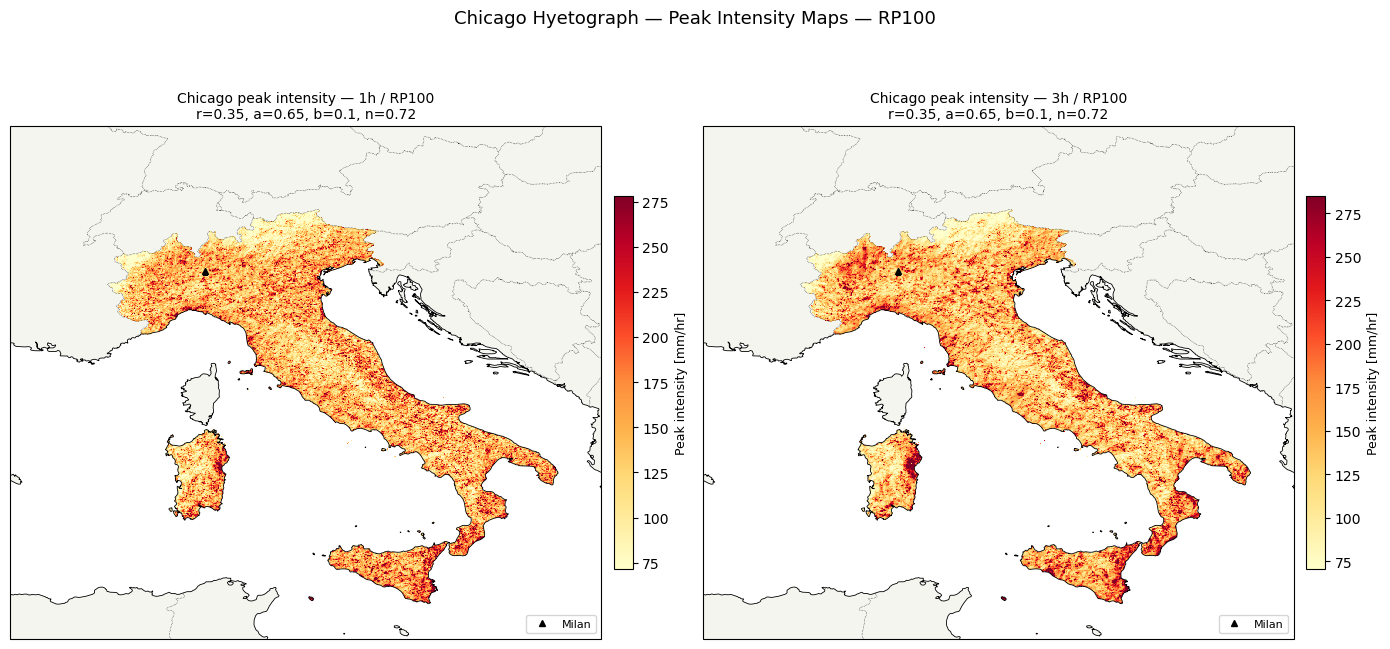

Saved → /home/admin_climatecharted_com/data/MOloch/IDF_results/chicago/chicago_peak_intensity_RP100.png


In [27]:
# ── 6.1 Peak intensity maps (one per duration) ────────────────────────────────
n_cols = len(DURATIONS)

if HAS_CARTOPY:
    proj = ccrs.PlateCarree()
    fig, axes = plt.subplots(
        1, n_cols, figsize=(7 * n_cols, 7),
        subplot_kw={'projection': proj}
    )
else:
    fig, axes = plt.subplots(1, n_cols, figsize=(7 * n_cols, 6))

if n_cols == 1:
    axes = [axes]

CMAP_PEAK = 'YlOrRd'

for ax, dur in zip(axes, DURATIONS):
    peak = peak_maps[dur].copy()
    peak[peak == 0] = np.nan          # mask dry / NaN pixels

    valid  = peak[np.isfinite(peak)]
    vmin_p = np.nanpercentile(valid, 2)
    vmax_p = np.nanpercentile(valid, 98)

    _make_map(
        ax, peak, lat_arr, lon_arr,
        title=(
            f'Chicago peak intensity — {dur}h / RP{TARGET_RP}\n'
            f'r={CHICAGO_R}, a={CHICAGO_A}, b={CHICAGO_B}, n={CHICAGO_N}'
        ),
        cmap=CMAP_PEAK,
        vmin=vmin_p, vmax=vmax_p,
        label='Peak intensity [mm/hr]',
        has_cartopy=HAS_CARTOPY
    )

    # mark reference point
    if HAS_CARTOPY:
        ax.plot(POINT_LON, POINT_LAT, 'k^', ms=5,
                transform=ccrs.PlateCarree(), zorder=5, label=POINT_NAME)
    else:
        ax.plot(POINT_LON, POINT_LAT, 'k^', ms=5, label=POINT_NAME)
    ax.legend(fontsize=8, loc='lower right')

plt.suptitle(
    f'Chicago Hyetograph — Peak Intensity Maps — RP{TARGET_RP}',
    fontsize=13, y=1.01
)
plt.tight_layout()
out_png = os.path.join(CHICAGO_DIR, f'chicago_peak_intensity_RP{TARGET_RP}.png')
fig.savefig(out_png, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {out_png}')

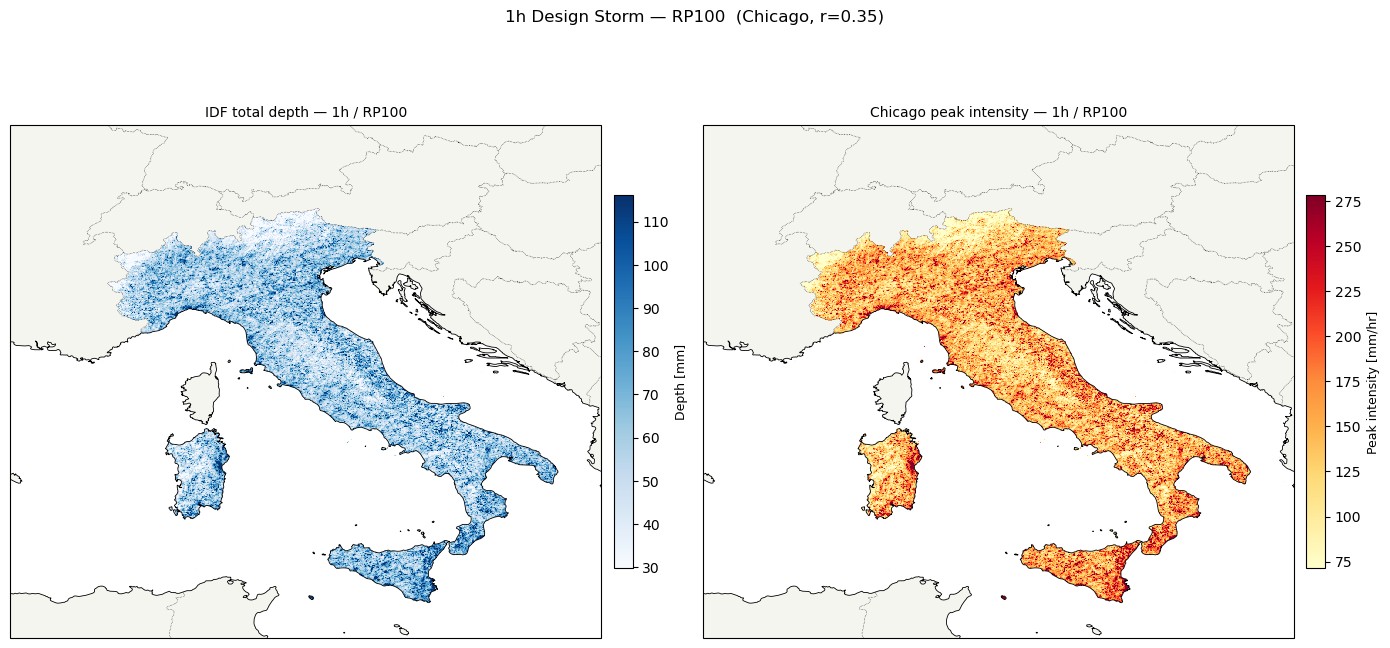

Saved → /home/admin_climatecharted_com/data/MOloch/IDF_results/chicago/chicago_depth_vs_peak_1h_RP100.png


In [28]:
# ── 6.2 Side-by-side: IDF depth vs Chicago peak intensity (1h) ───────────────
dur_check = 1   # change to 3 for the 3h event

if HAS_CARTOPY:
    proj = ccrs.PlateCarree()
    fig, (ax1, ax2) = plt.subplots(
        1, 2, figsize=(14, 7),
        subplot_kw={'projection': proj}
    )
else:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

depth_2d = idf_data[dur_check].values.copy()
depth_2d[depth_2d == 0] = np.nan

_make_map(
    ax1, depth_2d, lat_arr, lon_arr,
    title=f'IDF total depth — {dur_check}h / RP{TARGET_RP}',
    cmap='Blues', vmin=np.nanpercentile(depth_2d, 2),
    vmax=np.nanpercentile(depth_2d, 98),
    label='Depth [mm]', has_cartopy=HAS_CARTOPY
)

peak_check = peak_maps[dur_check].copy()
peak_check[peak_check == 0] = np.nan
_make_map(
    ax2, peak_check, lat_arr, lon_arr,
    title=f'Chicago peak intensity — {dur_check}h / RP{TARGET_RP}',
    cmap='YlOrRd', vmin=np.nanpercentile(peak_check[np.isfinite(peak_check)], 2),
    vmax=np.nanpercentile(peak_check[np.isfinite(peak_check)], 98),
    label='Peak intensity [mm/hr]', has_cartopy=HAS_CARTOPY
)

plt.suptitle(f'{dur_check}h Design Storm — RP{TARGET_RP}  (Chicago, r={CHICAGO_R})',
             fontsize=12, y=1.01)
plt.tight_layout()
side_png = os.path.join(CHICAGO_DIR,
                         f'chicago_depth_vs_peak_{dur_check}h_RP{TARGET_RP}.png')
fig.savefig(side_png, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {side_png}')

## 7. Export to NetCDF
Saves one NetCDF per duration containing:
- `peak_intensity`  (lat, lon) [mm/hr] — maximum instantaneous intensity
- `total_depth`     (lat, lon) [mm]    — reproduced total depth (sanity check)
- `hyetograph`      (time, lat, lon)   [mm/hr] — full time series (**only if** `SAVE_CUBE = True`)

In [29]:
# Set True to also export the full 4-D hyetograph cube (large!)
SAVE_CUBE = False

for dur in DURATIONS:
    peak   = peak_maps[dur]
    depth  = idf_data[dur].values
    t_min  = time_axes[dur]

    ds_out = xr.Dataset(
        {
            'peak_intensity': xr.DataArray(
                peak, dims=['lat', 'lon'],
                coords={'lat': lat_arr, 'lon': lon_arr},
                attrs={
                    'units': 'mm/hr',
                    'long_name': f'Chicago peak intensity {dur}h RP{TARGET_RP}',
                    'chicago_r': CHICAGO_R, 'idf_a': CHICAGO_A,
                    'idf_b': CHICAGO_B, 'idf_n': CHICAGO_N,
                    'dt_min': CHICAGO_DT,
                }
            ),
            'total_depth': xr.DataArray(
                depth, dims=['lat', 'lon'],
                coords={'lat': lat_arr, 'lon': lon_arr},
                attrs={'units': 'mm',
                       'long_name': f'GEV return depth {dur}h RP{TARGET_RP}'}
            ),
        },
        attrs={
            'description': 'Chicago (Keifer & Chu) hyetograph applied to MORE IDF rasters',
            'return_period_years': TARGET_RP,
            'duration_hours': dur,
        }
    )

    if SAVE_CUBE:
        ds_out['hyetograph'] = xr.DataArray(
            hyeto_cubes[dur],
            dims=['time_min', 'lat', 'lon'],
            coords={'time_min': t_min, 'lat': lat_arr, 'lon': lon_arr},
            attrs={'units': 'mm/hr', 'long_name': 'Chicago intensity time series'}
        )

    nc_path = os.path.join(CHICAGO_DIR,
                            f'chicago_{dur}h_RP{TARGET_RP}.nc')
    ds_out.to_netcdf(nc_path, encoding={
        'peak_intensity': {'dtype': 'float32', 'zlib': True, 'complevel': 4},
        'total_depth':    {'dtype': 'float32', 'zlib': True, 'complevel': 4},
    })
    print(f'Saved → {nc_path}')

Saved → /home/admin_climatecharted_com/data/MOloch/IDF_results/chicago/chicago_1h_RP100.nc
Saved → /home/admin_climatecharted_com/data/MOloch/IDF_results/chicago/chicago_3h_RP100.nc


## 8. Summary statistics

In [30]:
print(f'Chicago hyetograph summary — RP{TARGET_RP}')
print(f'Parameters: r={CHICAGO_R}, a={CHICAGO_A}, b={CHICAGO_B}, n={CHICAGO_N}, Δt={CHICAGO_DT} min')
print()
header = f'{"Duration":>10s}{"Depth min":>12s}{"Depth max":>12s}{"Peak i min":>12s}{"Peak i max":>12s}{"Peak i mean":>13s}'
print(header)
print('─' * len(header))

for dur in DURATIONS:
    depth = idf_data[dur].values
    peak  = peak_maps[dur]
    mask  = np.isfinite(peak) & (peak > 0)
    print(
        f'{str(dur)+"h":>10s}'
        f'{np.nanmin(depth):12.1f}'
        f'{np.nanmax(depth):12.1f}'
        f'{peak[mask].min():12.1f}'
        f'{peak[mask].max():12.1f}'
        f'{peak[mask].mean():13.1f}'
    )

Chicago hyetograph summary — RP100
Parameters: r=0.35, a=0.65, b=0.1, n=0.72, Δt=5.0 min

  Duration   Depth min   Depth max  Peak i min  Peak i max  Peak i mean
───────────────────────────────────────────────────────────────────────
        1h        14.2      1509.7        34.1      3616.8        149.3
        3h        24.6       514.0        39.5       823.8        149.0


---
## Notes

### Chicago (Keifer & Chu) formula
The instantaneous intensity on each limb of the hyetograph is:

**Before peak** (`t ≤ r·D`):  
$$i(t) = a \cdot \frac{(1-n)\, t_a + b}{(t_a + b)^{n+1}}, \quad t_a = t / r$$

**After peak** (`t > r·D`):  
$$i(t) = a \cdot \frac{(1-n)\, t_a + b}{(t_a + b)^{n+1}}, \quad t_a = (D - t) / (1 - r)$$

where `D` is the total duration [hr], `r` the peak-position ratio, and `a, b, n`
are the IDF parameters.

### Pixel-wise IDF parameters
For maximum accuracy, derive `a` and `n` by fitting the power-law IDF to the GEV
return values across the five durations (1h, 3h, 6h, 12h, 24h) at each pixel.  
A simple log-linear regression of `log(i) = log(a) − n·log(t + b)` suffices.  
Save the fitted maps and uncomment Section 3b.

### Choosing `r`
Italian meteorological practice typically uses `r = 0.35` (peak at 35% of event
duration), consistent with convective storm structures observed in the Po Valley
and the Apennines.  Coastal Mediterranean zones sometimes use `r = 0.40`.

### Output files
| File | Contents |
|------|----------|
| `chicago_1h_RP{n}.nc` | peak_intensity, total_depth rasters |
| `chicago_3h_RP{n}.nc` | peak_intensity, total_depth rasters |
| `chicago_peak_intensity_RP{n}.png` | side-by-side spatial maps |
| `chicago_hyetograph_<city>_RP{n}.png` | single-point time series |
